# LIMPIEZA DE DATOS (EDA)

## 1. El problema del negocio

¿Que perfil tienen los clientes con mayor potencial de conversion?

Es el problema de negocio que quiere determinar una entidad bancaria al contratar una empresa de analisis de datos que se encargue en contactar telefonicamente y mediante los datos a posibles clientes para determinar si estan interesados o no en adquirir un certificado de deposito a termino con el banco (entidad bancaria)

## 2. El set de datos

La informacion recolecta por la empresa se encuentra en un archivo CSV (dataset_banco.csv) con 45215 filas y 17 columnas

1. "age":  edad (numérica)
2. "job": tipo de trabajo (categórica: "admin.", "unknown", "unemployed", "management", "housemaid", "entrepreneur", "student", "blue-collar","self-employed", "retired", "technician", "services")
3. "marital": estado civil (categórica: "married", "divorced", "single")
4. "education": nivel educativo (categórica: "unknown", "secondary", "primary", "tertiary")
5. "default": si dejó de pagar sus obligaciones (categórica: "yes", "no")
6. "balance": saldo promedio anual en euros (numérica)
7. "housing": ¿tiene o no crédito hipotecario? (categórica: "yes", "no")
8. "loan": ¿tiene créditos de consumo? (categórica: "yes", "no")
9. "contact": medio a través del cual fue contactado (categórica: "unknown", "telephone", "cellular")
10. "day": último día del mes en el que fue contactada (numérica)
11. "month": último mes en el que fue contactada (categórica: "jan", "feb", "mar", ..., "nov", "dec")
12. "duration": duración (en segundos) del último contacto (numérica)
13. "campaign": número total de veces que fue contactada durante la campaña (numérica)
14. "pdays": número de días transcurridos después de haber sido contactado antes de la campaña actual (numérica. -1 indica que no fue contactado previamente)
15. "previous": número de veces que ha sido contactada antes de esta campaña (numérica)
16. "poutcome": resultado de la campaña de marketing anterior (categórica: "unknown", "other", "failure", "success")
17. "y": categoría ¿el cliente se suscribió a un depósito a término? (categórica: "yes", "no")

## 3. Explorando el dataset

In [1]:
# importar librerias
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# lectura del dataset
data = pd.read_csv('../data/dataset_banco.csv')
data

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143.0,yes,no,unknown,5,may,261.0,1,-1.0,0,unknown,no
1,44,technician,single,secondary,no,29.0,yes,no,unknown,5,may,151.0,1,-1.0,0,unknown,no
2,33,entrepreneur,married,secondary,no,2.0,yes,yes,unknown,5,may,76.0,1,-1.0,0,unknown,no
3,47,blue-collar,married,unknown,no,1506.0,yes,no,unknown,5,may,92.0,1,-1.0,0,unknown,no
4,33,unknown,single,unknown,no,1.0,no,no,unknown,5,may,198.0,1,-1.0,0,unknown,no
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
45210,51,technician,married,tertiary,no,825.0,no,no,cellular,17,nov,977.0,3,-1.0,0,unknown,yes
45211,71,retired,divorced,primary,no,1729.0,no,no,cellular,17,nov,456.0,2,-1.0,0,unknown,yes
45212,72,retired,married,secondary,no,5715.0,no,no,cellular,17,nov,1127.0,5,184.0,3,success,yes
45213,57,blue-collar,married,secondary,no,668.0,no,no,telephone,17,nov,508.0,4,-1.0,0,unknown,no


In [3]:
# mostrar en pantalla los 5 primeros registros
data.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143.0,yes,no,unknown,5,may,261.0,1,-1.0,0,unknown,no
1,44,technician,single,secondary,no,29.0,yes,no,unknown,5,may,151.0,1,-1.0,0,unknown,no
2,33,entrepreneur,married,secondary,no,2.0,yes,yes,unknown,5,may,76.0,1,-1.0,0,unknown,no
3,47,blue-collar,married,unknown,no,1506.0,yes,no,unknown,5,may,92.0,1,-1.0,0,unknown,no
4,33,unknown,single,unknown,no,1.0,no,no,unknown,5,may,198.0,1,-1.0,0,unknown,no


In [4]:
# estructura del dataset
data.shape

(45215, 17)

In [5]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 45215 entries, 0 to 45214
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   age        45215 non-null  int64  
 1   job        45213 non-null  str    
 2   marital    45214 non-null  str    
 3   education  45214 non-null  str    
 4   default    45215 non-null  str    
 5   balance    45213 non-null  float64
 6   housing    45215 non-null  str    
 7   loan       45215 non-null  str    
 8   contact    45215 non-null  str    
 9   day        45215 non-null  int64  
 10  month      45215 non-null  str    
 11  duration   45214 non-null  float64
 12  campaign   45215 non-null  int64  
 13  pdays      45214 non-null  float64
 14  previous   45215 non-null  int64  
 15  poutcome   45215 non-null  str    
 16  y          45215 non-null  str    
dtypes: float64(3), int64(4), str(10)
memory usage: 5.9 MB


In [6]:
data.describe()

,age,balance,day,duration,campaign,pdays,previous
count,45215.000000,45213.000000,45215.000000,45214.000000,45215.000000,45214.000000,45215.000000
mean,41.004711,1374.159866,15.805839,258.074357,2.763729,40.192485,0.580383
std,12.036647,3924.255525,8.322473,257.605175,3.097910,100.120622,2.303438
min,18.000000,-8019.000000,1.000000,-1389.000000,1.000000,-1.000000,0.000000
25%,33.000000,72.000000,8.000000,103.000000,1.000000,-1.000000,0.000000
50%,39.000000,448.000000,16.000000,180.000000,2.000000,-1.000000,0.000000
75%,48.000000,1428.000000,21.000000,319.000000,3.000000,-1.000000,0.000000
max,776.000000,527532.000000,31.000000,4918.000000,63.000000,871.000000,275.000000


## 4. Limpieza de datos

1. Datos faltantes en alguna celda
2. Columnas irrelevantes (que no corresponden al problema que queremos resolver)
3. Registros (filas) repetidos
4. Valores extremos (outliers) en el caso de las variables numericas.
5. Error tipograficos en el caso de las variables categoricos

### 4.1 Datos faltantes

In [7]:
# eliminacion de datos faltantes - imputacion
data.dropna(inplace=True)
# data = data.dropna()
data.info()

<class 'pandas.DataFrame'>
Index: 45207 entries, 0 to 45214
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   age        45207 non-null  int64  
 1   job        45207 non-null  str    
 2   marital    45207 non-null  str    
 3   education  45207 non-null  str    
 4   default    45207 non-null  str    
 5   balance    45207 non-null  float64
 6   housing    45207 non-null  str    
 7   loan       45207 non-null  str    
 8   contact    45207 non-null  str    
 9   day        45207 non-null  int64  
 10  month      45207 non-null  str    
 11  duration   45207 non-null  float64
 12  campaign   45207 non-null  int64  
 13  pdays      45207 non-null  float64
 14  previous   45207 non-null  int64  
 15  poutcome   45207 non-null  str    
 16  y          45207 non-null  str    
dtypes: float64(3), int64(4), str(10)
memory usage: 6.2 MB


### 4.2 Columnas irrelevantes

In [8]:
data['job'].unique()

<StringArray>
[    'management',     'technician',   'entrepreneur',    'blue-collar',
        'unknown',     'Management',        'retired',         'admin.',
       'services',  'self-employed',     'MANAGEMENT',  'Self-employed',
     'unemployed',      'housemaid',        'student',       'Services',
        'Retired', 'administrative']
Length: 18, dtype: str

In [12]:
cols_cat = ['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'poutcome', 'y']
for col in cols_cat:
    print(f"Columna:  {col}: {data[col].unique()} subniveles")
    print("="*100)

Columna:  job: <StringArray>
[    'management',     'technician',   'entrepreneur',    'blue-collar',
        'unknown',     'Management',        'retired',         'admin.',
       'services',  'self-employed',     'MANAGEMENT',  'Self-employed',
     'unemployed',      'housemaid',        'student',       'Services',
        'Retired', 'administrative']
Length: 18, dtype: str subniveles
Columna:  marital: <StringArray>
['married', 'single', 'div.', 'divorced', 'DIVORCED', 'Single']
Length: 6, dtype: str subniveles
Columna:  education: <StringArray>
[ 'tertiary', 'secondary',   'unknown',   'primary', 'SECONDARY', 'Secondary',
   'Primary',      'sec.',  'Tertiary',       'UNK']
Length: 10, dtype: str subniveles
Columna:  default: <StringArray>
['no', 'yes']
Length: 2, dtype: str subniveles
Columna:  housing: <StringArray>
['yes', 'no']
Length: 2, dtype: str subniveles
Columna:  loan: <StringArray>
['no', 'yes', 'No', 'YES', 'Yes', 'NO']
Length: 6, dtype: str subniveles
Columna:  cont

In [13]:
for col in cols_cat:
    print(f"Columna:  {col}: {data[col].nunique()} subniveles")
    print("="*100)

Columna:  job: 18 subniveles
Columna:  marital: 6 subniveles
Columna:  education: 10 subniveles
Columna:  default: 2 subniveles
Columna:  housing: 2 subniveles
Columna:  loan: 6 subniveles
Columna:  contact: 5 subniveles
Columna:  month: 12 subniveles
Columna:  poutcome: 6 subniveles
Columna:  y: 2 subniveles


### 4.3 Filas repetidas

In [15]:
print(f"Tamaño de la data antes de eliminar filas repetidas: {data.shape}")
data.drop_duplicates(inplace=True)
print(f"Tamaño de la data despues de eliminar filas repetidas: {data.shape}")

Tamaño de la data antes de eliminar filas repetidas: (45207, 17)
Tamaño de la data despues de eliminar filas repetidas: (45203, 17)


### 4.4 Outliers en las variables numericas

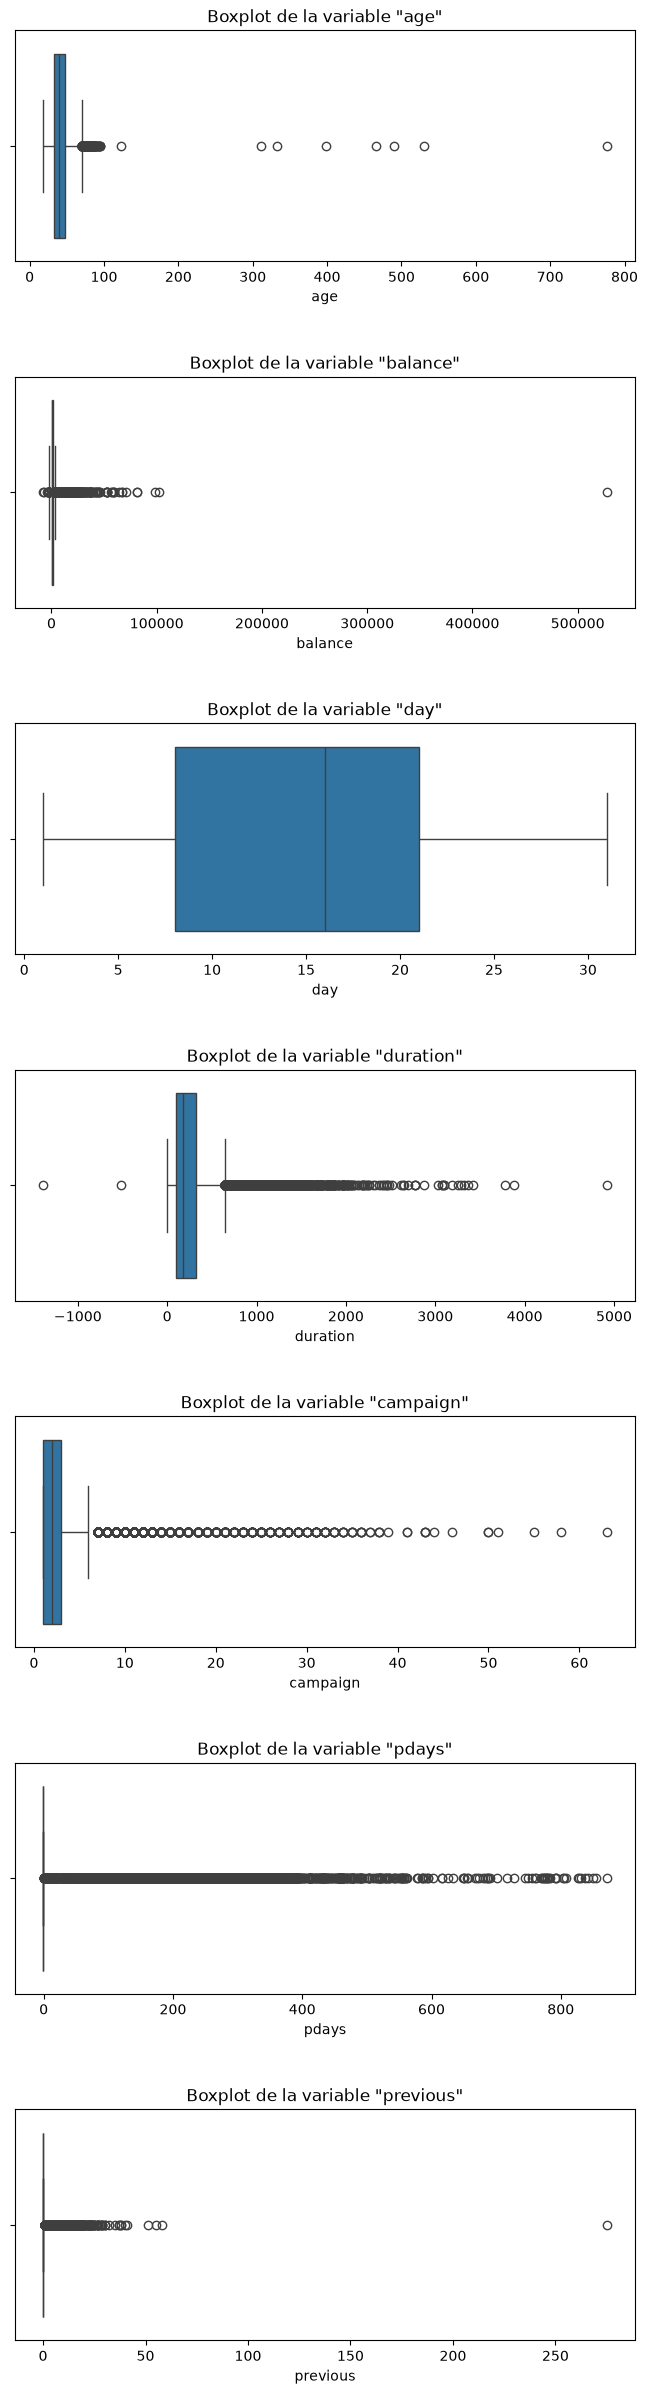

In [18]:
cols_num = ['age', 'balance', 'day', 'duration', 'campaign', 'pdays', 'previous']

fig, ax = plt.subplots(nrows=7, ncols=1, figsize=(8, 30))
fig.subplots_adjust(hspace=0.5)

for i, col in enumerate(cols_num):
    sns.boxplot(data=data, x=col, ax=ax[i])
    ax[i].set_title(f"Boxplot de la variable \"{col}\"")

**Observaciones:**

- `age`: hay sujetos con edades mucho mayores a 100 años
- `duration`: hay valores negativos
- `previous`: hay un valor extremadamente alto (cercano a 300)

In [19]:
# Eliminar filas con age > 100
print(f"Tamaño de la data antes de eliminar filas con age > 100: {data.shape}")
data = data[data['age'] <= 100]
print(f"Tamaño de la data despues de eliminar filas con age > 100: {data.shape}")

Tamaño de la data antes de eliminar filas con age > 100: (45203, 17)
Tamaño de la data despues de eliminar filas con age > 100: (45195, 17)


In [20]:
# eliminar filas con duracion < 0
print(f"Tamaño de la data antes de eliminar filas con duracion < 0: {data.shape}")
data = data[data['duration'] > 0]
print(f"Tamaño de la data despues de eliminar filas con duracion < 0: {data.shape}")

Tamaño de la data antes de eliminar filas con duracion < 0: (45195, 17)
Tamaño de la data despues de eliminar filas con duracion < 0: (45190, 17)


In [21]:
# eliminar filas con previous > 100
print(f"Tamaño de la data antes de eliminar filas con previous > 100: {data.shape}")
data = data[data['previous'] <= 100]
print(f"Tamaño de la data despues de eliminar filas con previous > 100: {data.shape}")

Tamaño de la data antes de eliminar filas con previous > 100: (45190, 17)
Tamaño de la data despues de eliminar filas con previous > 100: (45189, 17)


### 4.5 Errores tipograficos en variables categoricas

In [22]:
cols_cat

['job',
 'marital',
 'education',
 'default',
 'housing',
 'loan',
 'contact',
 'month',
 'poutcome',
 'y']

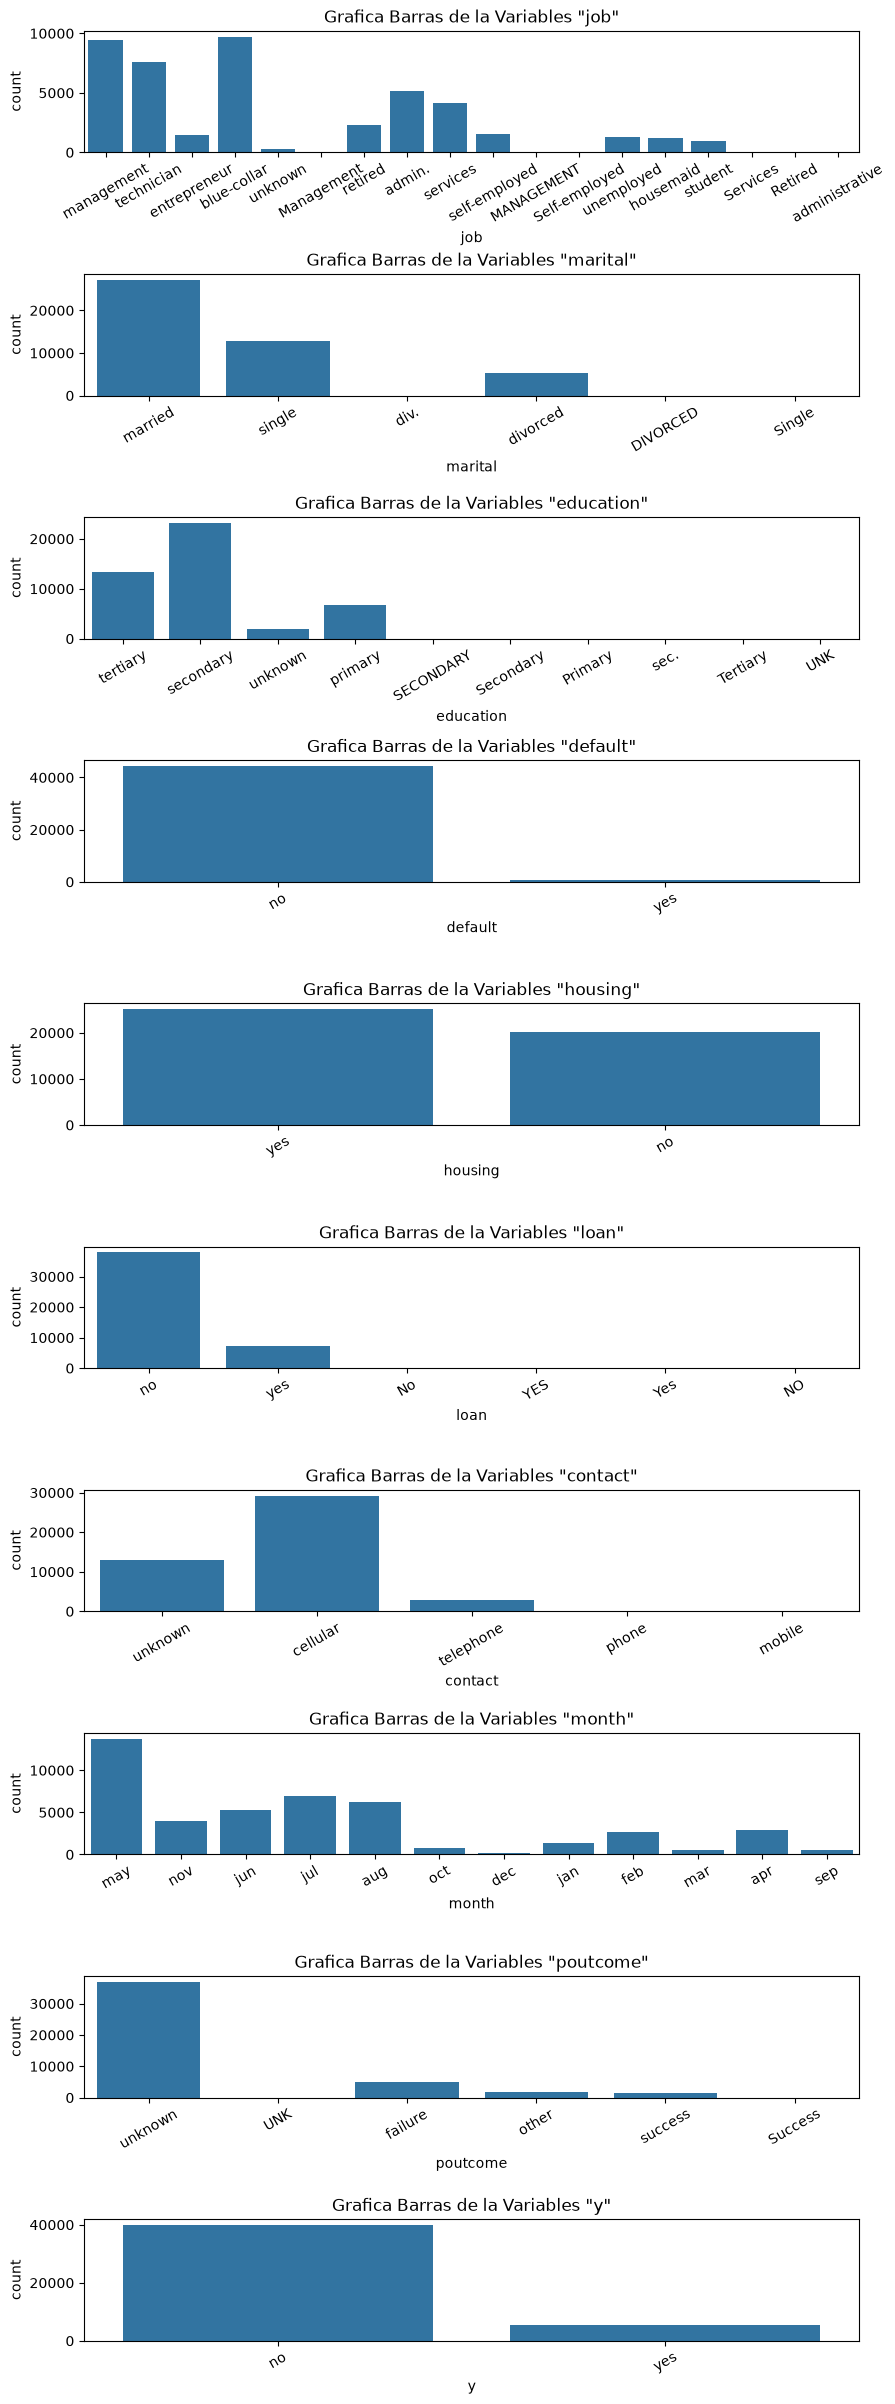

In [24]:
from matplotlib.ticker import FixedLocator

fig, ax = plt.subplots(nrows=10, ncols=1, figsize=(10, 30))
fig.subplots_adjust(hspace=1)

for i, col in enumerate(cols_cat):
    sns.countplot(data=data, x=col, ax=ax[i])
    ax[i].set_title(f"Grafica Barras de la Variables \"{col}\"")
    ax[i].set_xticks(ax[i].get_xticks())
    ax[i].set_xticklabels(ax[i].get_xticklabels(), rotation=30)

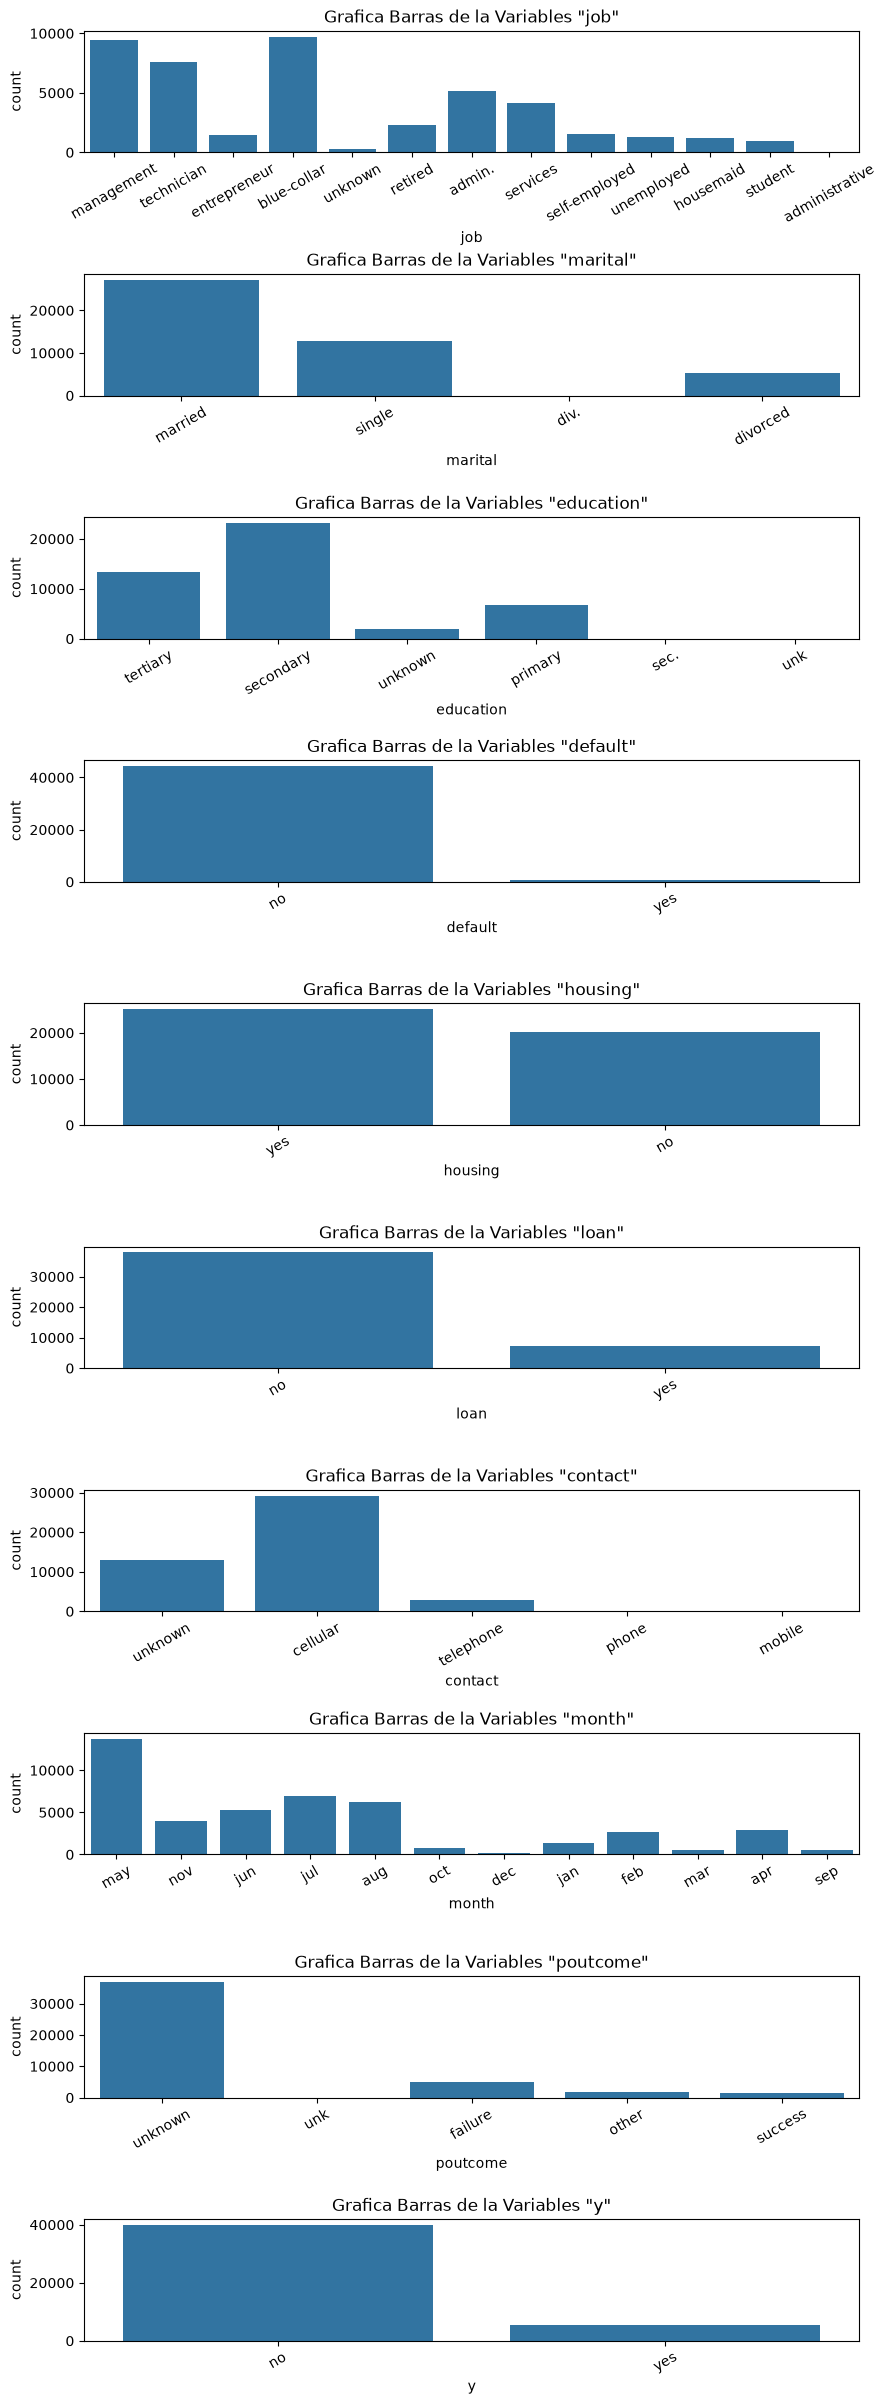

In [25]:
# representar en minusculas solo si la columna es categorica
for column in data.columns:
    if column in cols_cat:
        data[column] = data[column].str.lower()

fig, ax = plt.subplots(nrows=10, ncols=1, figsize=(10, 30))
fig.subplots_adjust(hspace=1)

for i, col in enumerate(cols_cat):
    sns.countplot(data=data, x=col, ax=ax[i])
    ax[i].set_title(f"Grafica Barras de la Variables \"{col}\"")
    ax[i].set_xticks(ax[i].get_xticks())
    ax[i].set_xticklabels(ax[i].get_xticklabels(), rotation=30)

In [28]:
# matiral: unificar div. y divorced
print(data['marital'].unique())
data['marital'] = data['marital'].str.replace('div.', 'divorced', regex=False)
print(data['marital'].unique())

<StringArray>
['married', 'single', 'div.', 'divorced']
Length: 4, dtype: str
<StringArray>
['married', 'single', 'divorced']
Length: 3, dtype: str


In [29]:
# education: unificar sec. y secondary -  unk y unknown
print(data['education'].unique())
data['education'] = data['education'].str.replace('sec.', 'secondary', regex=False)
data.loc[data['education']=='unk', 'education'] = 'unknown'
print(data['education'].unique())

<StringArray>
['tertiary', 'secondary', 'unknown', 'primary', 'sec.', 'unk']
Length: 6, dtype: str
<StringArray>
['tertiary', 'secondary', 'unknown', 'primary']
Length: 4, dtype: str


In [30]:
# contact: unificar telephone y phone
print(data['contact'].unique())
data.loc[data['contact']=='phone', 'contact'] = 'telephone'
data.loc[data['contact']=='mobile', 'contact'] = 'cellular'
print(data['contact'].unique())

<StringArray>
['unknown', 'cellular', 'telephone', 'phone', 'mobile']
Length: 5, dtype: str
<StringArray>
['unknown', 'cellular', 'telephone']
Length: 3, dtype: str


In [32]:
# poutcome: unificar unk y unknown
print(data['poutcome'].unique())
data.loc[data['poutcome']=='unk', 'poutcome'] = 'unknown'
print(data['poutcome'].unique())

<StringArray>
['unknown', 'unk', 'failure', 'other', 'success']
Length: 5, dtype: str
<StringArray>
['unknown', 'failure', 'other', 'success']
Length: 4, dtype: str


In [33]:
# job: unificar admin. y administrative
print(data['job'].unique())
data['job'] = data['job'].str.replace('admin.', 'administrative', regex=False)
print(data['job'].unique())

<StringArray>
[    'management',     'technician',   'entrepreneur',    'blue-collar',
        'unknown',        'retired',         'admin.',       'services',
  'self-employed',     'unemployed',      'housemaid',        'student',
 'administrative']
Length: 13, dtype: str
<StringArray>
[    'management',     'technician',   'entrepreneur',    'blue-collar',
        'unknown',        'retired', 'administrative',       'services',
  'self-employed',     'unemployed',      'housemaid',        'student']
Length: 12, dtype: str


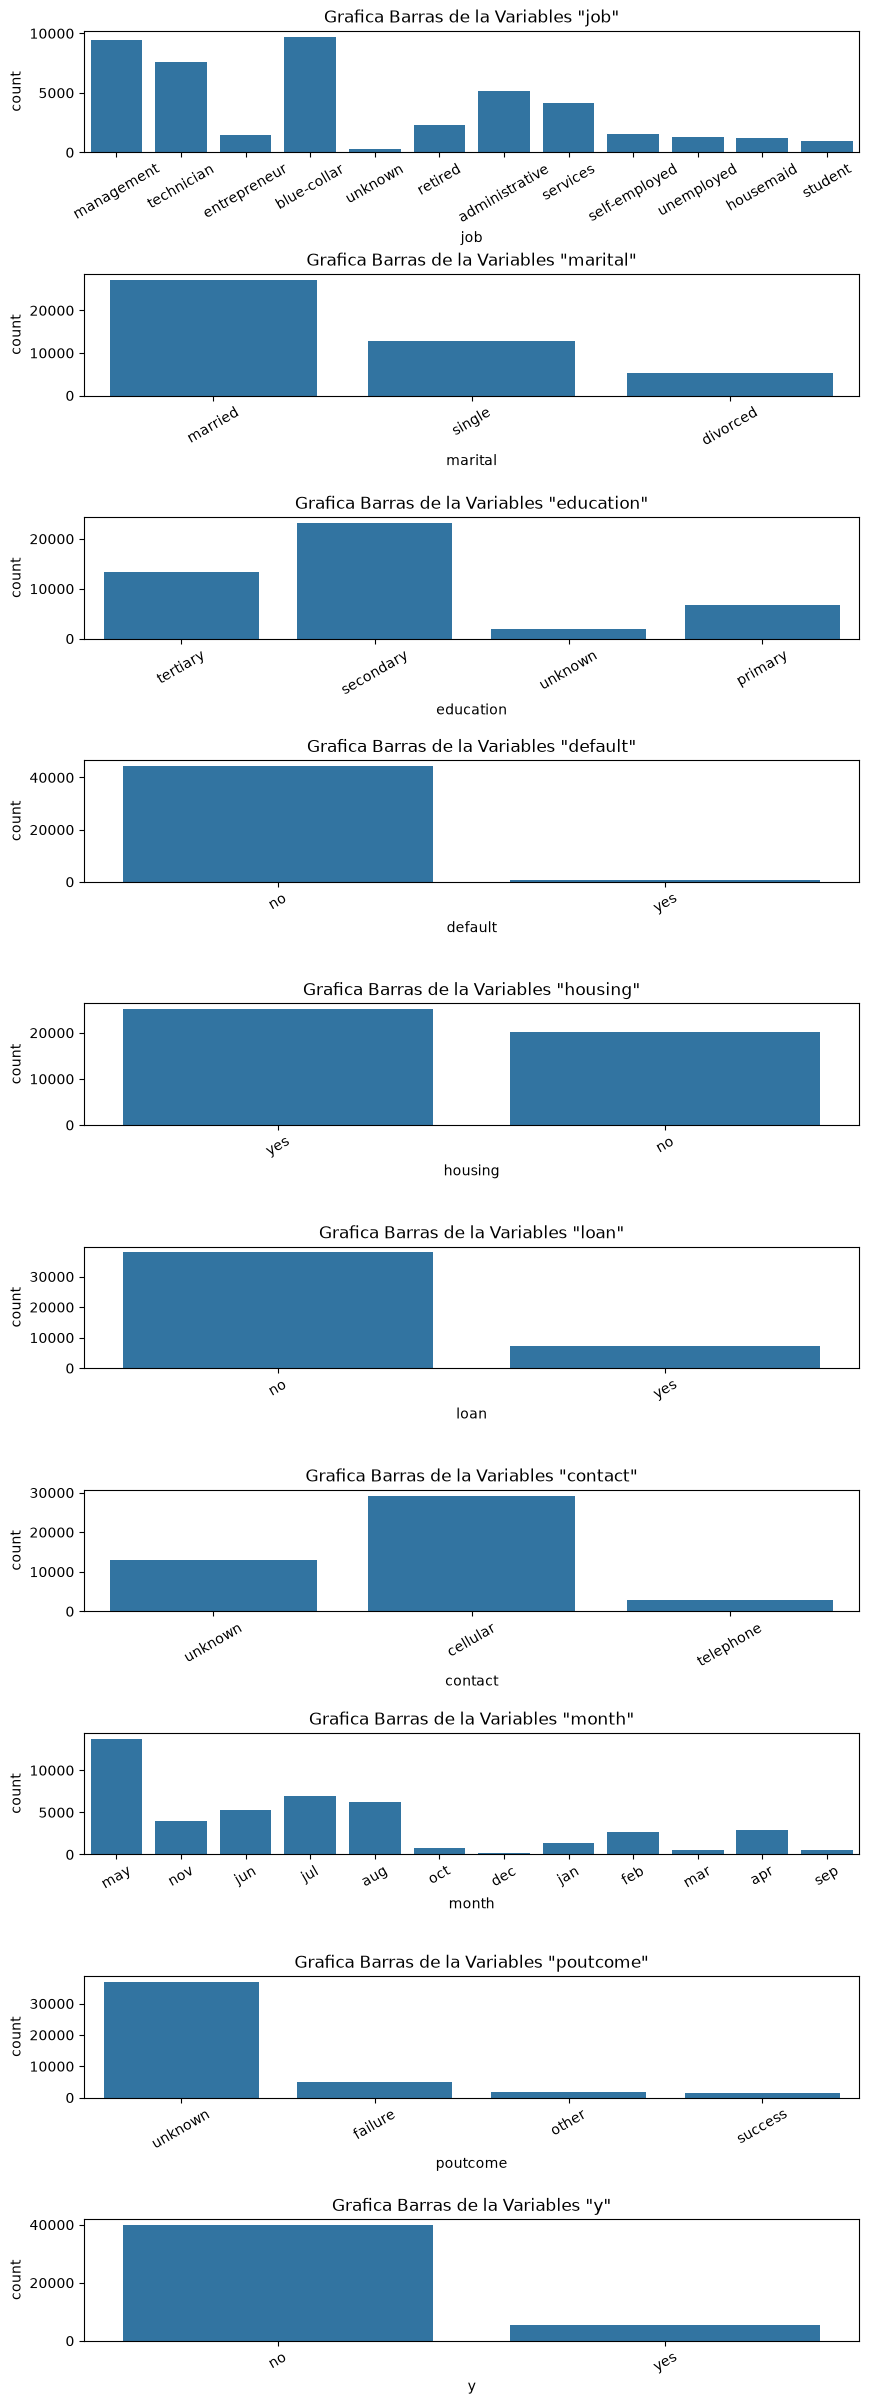

In [34]:
fig, ax = plt.subplots(nrows=10, ncols=1, figsize=(10, 30))
fig.subplots_adjust(hspace=1)

for i, col in enumerate(cols_cat):
    sns.countplot(data=data, x=col, ax=ax[i])
    ax[i].set_title(f"Grafica Barras de la Variables \"{col}\"")
    ax[i].set_xticks(ax[i].get_xticks())
    ax[i].set_xticklabels(ax[i].get_xticklabels(), rotation=30)

In [35]:
data.to_csv('../data/dataset_banco_limpio.csv', index=False)